# USAGE OF THE DIFFUSION MODEL

In [1]:
%run init_notebook.py

import torch.nn as nn
from torchvision.datasets import FashionMNIST, QMNIST, KMNIST
from torch.utils.data import DataLoader, TensorDataset
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt
import time
import json
from tqdm import tqdm  # import the class directly

import torchaudio
import torchaudio.transforms as T
from src.dataset import NSynth
import torch
from src.diffusion import *
from src.utils.models import adjust_shape, compute_magnitude_and_phase, compute_magnitude_and_phase_sin_cos
import math
from IPython.display import Audio, display

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

root = r"C:\Users\Articuno\Desktop\TFG-MUSICAL\data\models\diffusion"
paths = {
    'minst' : {
        'root': root + r"\minst",
        'model': root + r"\minst\model.pth",
        'object': root + r"\minst\object.pth",
        'config': root + r"\minst\config.json",
        'scheduler': root + r"\minst\scheduler.pth",
        'checkpoint': root + r"\minst\checkpoint.pth",
        'dataset' : r"C:\Users\Articuno\Desktop\TFG-info\data\mnist"
    },
    'audio' : {
        'root': root + r"\audio",
        'model': root + r"\audio\model.pth",
        'config': root + r"\audio\config.json",
        'object': root + r"\audio\object.pth",
        'scheduler': root + r"\audio\scheduler.pth",
        'checkpoint': root + r"\audio\checkpoint.pth"
    },
    'latent' : {
        'root': root + r"\latent",
        'model': root + r"\latent\model.pth",
        'object': root + r"\latent\object.pth",
        'config': root + r"\latent\config.json",
        'scheduler': root + r"\latent\scheduler.pth",
        'checkpoint': root + r"\latent\checkpoint.pth",
        'dataset_training' : r"C:\Users\Articuno\Desktop\TFG-MUSICAL\data\models\diffusion\latent\dataset\training.pt",
        'training_norm_params' :  r"C:\Users\Articuno\Desktop\TFG-MUSICAL\data\models\diffusion\latent\dataset\training_params.pt",
    }
}

def show_loss_plot(losses):
    epochs_list = [d['epoch'] for d in losses]
    loss_list   = [d['loss']  for d in losses]
    lr_list     = [d['lr']    for d in losses]

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

    ax1.plot(epochs_list, loss_list)
    ax1.set_ylabel('Loss')
    ax1.set_title('Training Loss')
    ax1.grid(True)

    ax2.plot(epochs_list, lr_list, color='orange')
    ax2.set_ylabel('Learning Rate')
    ax2.set_xlabel('Epoch')
    ax2.set_title('Learning Rate Schedule')
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

## LOAD MODELS

In [2]:
from src.diffusion_setups.setup_audio import setup_audio_model
from src.diffusion_setups.setup_minst import setup_minst_model
from src.diffusion_setups.setup_latent import setup_latent_model

def load_audio_model():
    config = {}
    with open(paths['audio']['config'], 'r') as f:
        config = json.load(f) 
    model, scheduler, _ = setup_audio_model(
        timesteps=config['timesteps'],
        channels=config['channels'],
        norm_groups=config['norm_groups'],
        emb_dim=config['emb_dim'],
        n_fft=config['n_fft'],
        hop_length=config['hop_length'],
        win_length=config['win_length']
    )
    model = torch.load(paths['audio']['model'])
    scheduler = torch.load(paths['audio']['scheduler'])
    return model, scheduler

def load_minst_model():
    config = {}
    with open(paths['minst']['config'], 'r') as f:
        config = json.load(f)  
    model, scheduler, _ = setup_minst_model(
        timesteps=config['timesteps'],
        channels=config['channels'],
        norm_groups=config['norm_groups'],
        emb_dim=config['emb_dim']
    )
    # model.load_state_dict(torch.load(paths['minst']['model']))
    model = torch.load(paths['minst']['model'])
    scheduler = torch.load(paths['minst']['scheduler'])
    return model, scheduler

def load_latent_model():
    config = {}
    with open(paths['latent']['config'], 'r') as f:
        config = json.load(f)    
    model, scheduler, _ = setup_latent_model(
        timesteps=config['timesteps'],
        emb_dim=config['emb_dim'],
        hidden_dims=config['hidden_dims'],
        latent_dim=config['latent_dim'],
        deep=config['deep'],
        increase_dims=config['increase_dims']
    )
    model = torch.load(paths['latent']['model'])
    scheduler = torch.load(paths['latent']['scheduler'])
    return model, scheduler

## SAMPLE IMAGES

In [ ]:
def sample_raw_img(model, scheduler, image_size=(1, 28, 28), num_images=1):
    model.eval() # NS
    # with torch.no_grad():
    
    x = torch.randn(num_images, *image_size, device=device) # imagen de ruidio inicial
    T = scheduler.alpha_bar.shape[0]
    
    betas = scheduler.beta
    alphas = scheduler.alpha
    alpha_bars = scheduler.alpha_bar
    with torch.no_grad():

        for t in reversed(range(T)):
            t_batch = torch.full((num_images,), t, device=device, dtype=torch.long)

            # predicción de ruido
            e_pred = model(x, t_batch)
            
            beta_t = betas[t]
            alpha_t = alphas[t]
            alpha_bar_t = alpha_bars[t]
            
            # beta_t = beta_t.view(1,1,1,1)
            # alpha_t = alpha_t.view(1,1,1,1)
            # alpha_bar_t = alpha_bar_t.view(1,1,1,1)


            # Coeficientes DDPM
            coef1 = 1 / torch.sqrt(alpha_t)
            coef2 = beta_t / torch.sqrt(1 - alpha_bar_t)

            mu = coef1 * (x - coef2 * e_pred)

            if t > 0:
                noise = torch.randn_like(x)
                # sigma_t = torch.sqrt(beta_t)
                sigma_t = torch.sqrt(beta_t * (1 - alpha_bars[t-1]) / (1 - alpha_bars[t]))

                x = mu + sigma_t * noise
            else:
                x = mu

        x = x.cpu()
        
    return x

def denoise_img(model, scheduler, noisy_img, step_imgs=10):
    model.eval()
    xs = [noisy_img]
    x = noisy_img.to(device)
    T = scheduler.alpha_bar.shape[0]
    
    betas = scheduler.beta
    alphas = scheduler.alpha
    alpha_bars = scheduler.alpha_bar
    
    with torch.no_grad():
        for t in reversed(range(T)):
            
            t_batch = torch.full((x.size(0),), t, device=device, dtype=torch.long)

            e_pred = model(x, t_batch)
            
            beta_t = betas[t]
            alpha_t = alphas[t]
            alpha_bar_t = alpha_bars[t]

            coef1 = 1 / torch.sqrt(alpha_t)
            coef2 = beta_t / torch.sqrt(1 - alpha_bar_t)

            mu = coef1 * (x - coef2 * e_pred)

            # if t > 0:
            #     noise = torch.randn_like(x)
            #     sigma_t = torch.sqrt(beta_t)
            #     x = mu + sigma_t * noise
            # else:
            #     x = mu
                        
            if t > 0:
                noise = torch.randn_like(x)
                # sigma_t = torch.sqrt(beta_t * (1 - alpha_bars[t-1]) / (1 - alpha_bars[t]))
                sigma_t = torch.sqrt(beta_t)
                x = mu + sigma_t * noise
            else:
                x = mu
                
            if t % (T // step_imgs) == 0:
                xs.append(x.cpu())
            
        xs.append(x.cpu())
    return xs
    
def show_imgs(xs, cols=5, color=False):
    rows = math.ceil(len(xs) / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))
    axes = axes.flatten()

    for i in range(len(xs)):
        img = xs[i][0].detach().cpu()
        if not color:  # grayscale (1, H, W)
            axes[i].imshow(img.squeeze().numpy(), cmap='gray')
        else:                   # RGB (3, H, W)
            axes[i].imshow(img.permute(1, 2, 0).numpy())
        axes[i].axis('off')

    # Ocultar ejes sobrantes si n no es múltiplo de cols
    for j in range(len(xs), len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
    
def sample_latent(model, scheduler, latent_dim=200, num_samples=1):
    model.eval()
    x = torch.randn(num_samples, latent_dim, device=device)
    T = scheduler.alpha_bar.shape[0]
    
    betas = scheduler.beta
    alphas = scheduler.alpha
    alpha_bars = scheduler.alpha_bar
    
    with torch.no_grad():
        for t in reversed(range(T)):
            t_batch = torch.full((num_samples,), t, device=device, dtype=torch.long)

            e_pred = model(x, t_batch)
            
            beta_t = betas[t]
            alpha_t = alphas[t]
            alpha_bar_t = alpha_bars[t]

            coef1 = 1 / torch.sqrt(alpha_t)
            coef2 = beta_t / torch.sqrt(1 - alpha_bar_t)

            mu = coef1 * (x - coef2 * e_pred)

            if t > 0:
                noise = torch.randn_like(x)
                sigma_t = torch.sqrt(beta_t)
                x = mu + sigma_t * noise
            else:
                x = mu

        x = x.cpu()
        
    return x

def get_sound(x, n_fft=1500, win_length=1500, hop_length=250):
    
    istft_transform = T.InverseSpectrogram(
        n_fft=n_fft, win_length=win_length, hop_length=hop_length, onesided=False
    ).to(device)
    
    mag   = x[:, 0, :, :]         # (B, H, W)
    phase = x[:, 1, :, :]         # (B, H, W)
    
    complex_stft = mag * torch.exp(1j * phase)  # (B, H, W)

    # Inverse STFT to waveform
    wave = istft_transform(complex_stft)  # (B, T)

    wave = wave.squeeze().cpu().numpy()
    print(wave.shape)
    return wave

def sample_audio(VAE, latent_model, scheduler, n_fft=1500, win_length=1500, hop_length=250, num_samples=1):
    latent_samples = sample_latent(latent_model, scheduler, num_samples=num_samples)
    ws = []
    for l in latent_samples:
        x = VAE.decode(l.unsqueeze(0).to(device))  # (1, 2, H, W)
        wave = get_sound(x, n_fft=n_fft, win_length=win_length, hop_length=hop_length)
        ws.append(wave)
    return ws

def display_audio(waves, sample_rate=16000):
    for wave in waves:
        display(Audio(wave, rate=sample_rate))
        
def display_tensor(tensor):
    """
    Muestra un tensor de shape [1, 2, 1500, 251] en grande.
    Muestra cada canal por separado.
    """
    # tensor: [1, 2, 1500, 251]
    assert tensor.shape == torch.Size([1, 2, 1500, 251]), f"Shape inesperado: {tensor.shape}"

    batch = tensor[0]  # [2, 1500, 251]
    num_canales = batch.shape[0]

    fig, axes = plt.subplots(1, num_canales, figsize=(20, 10))

    for i in range(num_canales):
        canal = batch[i].detach().cpu().numpy()  # [1500, 251]
        axes[i].imshow(canal, aspect='auto', origin='lower', cmap='viridis')
        axes[i].set_title(f'Canal {i+1}', fontsize=16)
        axes[i].set_xlabel('Anchura (251)', fontsize=12)
        axes[i].set_ylabel('Altura (1500)', fontsize=12)
        plt.colorbar(axes[i].images[0], ax=axes[i])

    plt.suptitle('Tensor [1, 2, 1500, 251]', fontsize=20)
    plt.tight_layout()
    plt.show()



## Sampling images/vectors from noise

In [4]:
MNIST = False
if MNIST:
    mnist_model, mnist_scheduler = load_minst_model()
    xs = sample_raw_img(mnist_model, mnist_scheduler, num_images=10)
    # xs = torch.randn(1, 1, 28, 28).to(device)
    # xs = denoise_img(mnist_model, mnist_scheduler, noisy_img=torch.randn(1, 1, 28, 28).to(device), step_imgs=8)
    # print(x.shape)
    show_imgs(xs, cols=5)
    del mnist_model, mnist_scheduler

In [5]:
AUDIO = False
if AUDIO:
    with open(paths['audio']['config'], 'r') as f:
        config = json.load(f)  
    height = config['n_fft'] // 2 +1
    width = height
    audio_model, audio_scheduler = load_audio_model()
    x, xs = denoise_img(audio_model, audio_scheduler, noisy_img=torch.randn(1, 3, height, width).to(device), step_imgs=10)
    print(x.shape)
    show_imgs(xs, cols=5)
    del audio_model, audio_scheduler

In [6]:
LATENT = False
if LATENT:
    latent_model, latent_scheduler = load_latent_model()
    x = sample_latent(latent_model, latent_scheduler, latent_dim=200, num_samples=1)
    print(x.shape)
    print(x)
    del latent_model, latent_scheduler

## Using the VAE decoder to generate images from latent vectors

In [7]:
from src.models import VAE

def load_vae(input_height=1500, input_width=251, latent_dim=200, channels=[2,16,32,64], model_path=r"C:\Users\Articuno\Desktop\TFG-info\data\models\vae.pth"):
    model = VAE((input_height, input_width), latent_dim=latent_dim, channels=channels).to(device)
    model.load_state_dict(torch.load(model_path))
    model.eval()
    print("VAE Loaded")
    return model

VAE Loaded
torch.Size([1, 200])
torch.Size([1, 2, 1500, 251])


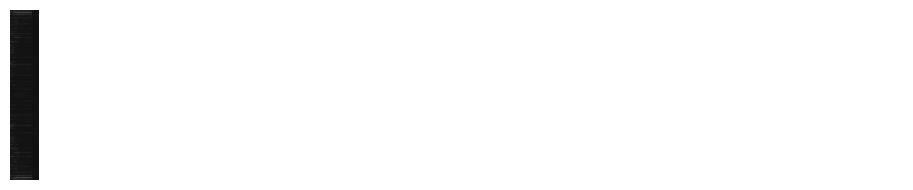

(62500,)


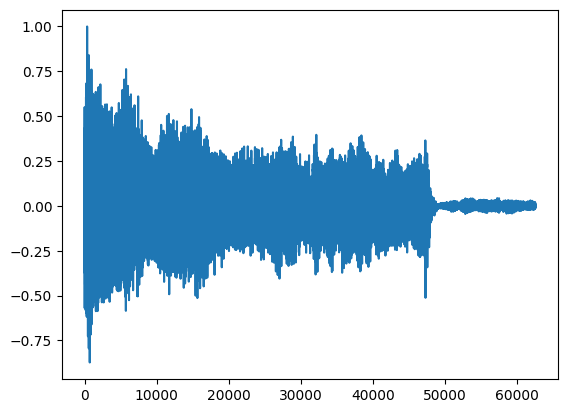

In [11]:
import soundfile as sf
import numpy as np

LATENT_VAE = True
if LATENT_VAE:
    latent_model, latent_scheduler = load_latent_model()
    z = sample_latent(latent_model, latent_scheduler, latent_dim=200, num_samples=1).to(device)
    del latent_model, latent_scheduler
    vae_model = load_vae()
    with torch.no_grad():
        x = vae_model.decoder(z)
    print(z.shape)
    print(x.shape)
    show_imgs(x)    
    wave = get_sound(x)
    display(Audio(wave, rate=16000))
    wave = wave / (np.abs(wave).max() + 1e-8)  # normaliza
    sf.write('output.wav', wave, 16000)
    plt.plot(wave)


In [ ]:
import soundfile as sf
import numpy as np

LATENT_VAE = True
if LATENT_VAE:
    latent_model, latent_scheduler = load_latent_model()
    waves = sample_audio(load_vae(), latent_model, latent_scheduler, num_samples=3)
    del latent_model, latent_scheduler
    display_audio(waves)
